# Garbage Classification using CNN in PyTorch
This project applies deep learning techniques to classify garbage images into one of 10 predefined categories:
- **battery**
- **biological**
- **cardboard**
- **clothes**
- **glass**
- **metal**
- **paper**
- **plastic**
- **shoes**
- **trash**

### Objectives:
- Build and train a CNN using PyTorch for image classification.
- Use image transformations like resizing, flipping, and rotation to improve learning.
- Handle class imbalance by adjusting the loss function.
- Measure how well the model performs using accuracy and a confusion matrix.
- Show sample predictions to better understand how the model works.

### Dataset:
The dataset is stored in a folder named `garbage_dataset_v2`, placed in the same directory as this notebook.
It contains 10 subfolders, one for each garbage category.
Images are resized to 128×128 and split into training and validation sets (80% / 20%).

### Model:
The model has 4 convolutional layers to extract features from images.
After that, a fully connected layer and dropout are used to make the final predictions.
The model is trained using the Adam optimizer and tested on the validation set.

## 1. Checking for GPU Availability
This cell checks if a GPU (CUDA-enabled device) is available.
If a GPU is available, it prints the device name.
If not, the training will fall back to using the CPU.

Using a GPU can significantly speed up training time for deep learning models.
The model in this notebook was trained on Nvidia Geforce RTX 4050 Laptop

In [1]:
import torch

# Check if CUDA (GPU) is available
print("CUDA available:", torch.cuda.is_available())

# Get GPU device name
if torch.cuda.is_available():
    print("GPU Device Name:", torch.cuda.get_device_name(0))
else:
    print("Training will use CPU.")

CUDA available: True
GPU Device Name: NVIDIA GeForce RTX 4050 Laptop GPU


## 2. Load and Transform Dataset

We use `ImageFolder` to load the dataset from the `garbage_dataset_v2` folder.  
This folder contains 10 subfolders: `battery`, `biological`, `cardboard`, `clothes`, `glass`, `metal`, `paper`, `plastic`, `shoes`, and `trash`.  
Each subfolder name is automatically assigned as the class label.

### Preprocessing Steps:
- **Resize** each image to 128×128 pixels  
- **RandomHorizontalFlip** to simulate flipped images  
- **RandomRotation** by up to ±10° to introduce variability  
- **Convert** each image to a PyTorch tensor  

### Dataset Splitting:
The dataset is split into:
- **Training set**: 80% of the data  
- **Validation set**: 20% of the data  

We use `random_split()` to divide the data while keeping the class distribution approximately balanced.

### Data Batching:
We wrap the training and validation sets in `DataLoader` objects:
- **Batch size**: 32 images per batch  
- **Shuffling**: Enabled for training set only  

### Tensor Conversion Formula:
Each image is converted to a tensor where pixel values are normalized to the range [0, 1]:

$$
x_{tensor} = \frac{x}{255}
$$

Where \( x \) is the original pixl value in the range [0, 255].


In [2]:
# Import necessary libraries
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, random_split

# Define a set of image transformations (data augmentation)
transform = transforms.Compose([
    transforms.Resize((128, 128)),         # Resize all images to 128x128
    transforms.RandomHorizontalFlip(),     # Randomly flip some images horizontally
    transforms.RandomRotation(10),         # Randomly rotate some images by up to 10 degrees
    transforms.ToTensor()                  # Convert images to PyTorch tensors
])

# Load dataset from a folder organized by class subfolders
dataset = datasets.ImageFolder("garbage_dataset_v2", transform=transform)

# Automatically extract class names based on subfolder names
classes = dataset.classes

# Split dataset into 80% training and 20% validation sets
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create DataLoaders to load data in batches
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)   # Shuffling for training
val_loader = DataLoader(val_dataset, batch_size=32)                     # No shuffle for validation

## 3. Define CNN Architecture

We define a custom Convolutional Neural Network (CNN) with four convolutional layers and two fully connected layers.  
The architecture extracts image features through convolution and pooling, then classifies the output into one of 10 garbage categories.

### Layer Structure:
1. **Conv2D**: 3 input channels → 32 filters → ReLU → MaxPool  
2. **Conv2D**: 32 → 64 filters → ReLU → MaxPool  
3. **Conv2D**: 64 → 128 filters → ReLU → MaxPool  
4. **Conv2D**: 128 → 256 filters → ReLU → MaxPool  
5. **Flatten**: Converts 256×8×8 feature maps into a 1D vector  
6. **FC**: 256×8×8 → 128 neurons → ReLU → Dropout  
7. **FC**: 128 → 10 output classes (for classification)

### Convolution Formula:
$$
h_{i,j}^{(k)} = \sum_{m,n} x_{i+m,j+n} \cdot w_{m,n}^{(k)} + b^{(k)}
$$

Where:
- <i>x</i>: input patch  
- <i>w</i><sup>(k)</sup>: weights of the k-th filter  
- <i>b</i><sup>(k)</sup>: bias for filter k  
- <i>h</i><sup>(k)</sup>: output feature map  


In [3]:
# Import necessary libraries
import torch.nn as nn
import torch.nn.functional as F

# Define the CNN architecture
class GarbageCNN(nn.Module):
    def __init__(self):
        super(GarbageCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)      # Output: 32 x 128 x 128
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)     # Output: 64 x 64 x 64
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)    # Output: 128 x 32 x 32
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)   # Output: 256 x 16 x 16

        # Max pooling (reduces each dimension by 2)
        self.pool = nn.MaxPool2d(2, 2)

        # Fully connected layers
        # After 4 pooling layers: input becomes 256 x 8 x 8 = 16384 features
        self.fc1 = nn.Linear(256 * 8 * 8, 128)  
        self.dropout = nn.Dropout(0.3)   # Dropout to prevent overfitting
        self.fc2 = nn.Linear(128, 10)    # Output layer for 10 classes

    def forward(self, x):
        # Apply conv layers with ReLU and max pooling
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))

        # Flatten the tensor for fully connected layer
        x = x.view(-1, 256 * 8 * 8)

        # Fully connected layer with ReLU and dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        # Output layer (raw logits, softmax is applied in loss function)
        x = self.fc2(x)
        return x

## 4. Model Training with Class Weights

This cell sets up the model for training, computes class weights to handle imbalance, and trains the model for a fixed number of epochs.

### Why Use Class Weights?
Some classes in the dataset appear more frequently than others. To prevent the model from being biased toward the larger classes, we calculate weights for each class and use them in the loss function. This makes the model pay more attention to underrepresented classes.

We use `compute_class_weight` from `sklearn` to calculate balanced weights.

### Training Process:
For each epoch:
1. Set model to **training mode**
2. For each batch:
   - Move data to device (CPU or GPU)
   - Perform **forward pass** to compute predictions
   - Compute **weighted cross-entropy loss**
   - Perform **backward pass** to compute gradients
   - Update model weights using **Adam optimizer**

### Cross-Entropy Loss Formula:
$$
\mathcal{L} = - \sum_{i=1}^{C} w_i \cdot y_i \cdot \log(\hat{y}_i)
$$

Where:<br>
- <i>C</i>: number of classes<br>
- <i>y<sub>i</sub></i>: true label (one-hot)<br>
- <i>&#770;y<sub>i</sub></i>: predicted probability for class <i>i</i><br>
- <i>w<sub>i</sub></i>: class weight for class <i>i</i>

### Training Settings:
- Optimizer: Adam  
- Learning rate: 0.001  
- Loss: CrossEntropyLoss (with class weights)  
- Epochs: 40  
- Batch size: 32  


In [4]:
# Import necessary libraries
import torch.optim as optim
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Set device to GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create an instance of the model and move it to the device
model = GarbageCNN().to(device)

# Compute class weights based on frequency of each class in training data
train_targets = [dataset[i][1] for i in train_dataset.indices]
class_weights = compute_class_weight(
    class_weight='balanced',           # Balance based on class frequencies
    classes=np.unique(train_targets),
    y=train_targets
)

# Convert class weights to a PyTorch tensor and move to device
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# Define the loss function using the computed class weights and set up the optimizer (Adam)
criterion = nn.CrossEntropyLoss(weight = class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Set number of epochs and training loop
num_epochs = 40
for epoch in range(num_epochs):
    model.train()         # Set model to training mode
    running_loss = 0.0    # Track loss for each epoch
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device) # Move batch to device

        optimizer.zero_grad()              # Clear previous gradients
        outputs = model(images)            # Forward pass
        loss = criterion(outputs, labels)  # Compute loss
        loss.backward()                    # Backward pass
        optimizer.step()                   # Update model weights

        running_loss += loss.item()        # Accumulate loss
    
    # Print average loss for the epoch
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader):.4f}")


Epoch 1, Loss: 1.9272
Epoch 2, Loss: 1.5995
Epoch 3, Loss: 1.4366
Epoch 4, Loss: 1.3269
Epoch 5, Loss: 1.2400
Epoch 6, Loss: 1.1315
Epoch 7, Loss: 1.0836
Epoch 8, Loss: 1.0206
Epoch 9, Loss: 0.9469
Epoch 10, Loss: 0.9014
Epoch 11, Loss: 0.8614
Epoch 12, Loss: 0.8108
Epoch 13, Loss: 0.7742
Epoch 14, Loss: 0.7499
Epoch 15, Loss: 0.7065
Epoch 16, Loss: 0.6811
Epoch 17, Loss: 0.6411
Epoch 18, Loss: 0.6243
Epoch 19, Loss: 0.6111
Epoch 20, Loss: 0.5910
Epoch 21, Loss: 0.5567
Epoch 22, Loss: 0.5529
Epoch 23, Loss: 0.5169
Epoch 24, Loss: 0.5143
Epoch 25, Loss: 0.4745
Epoch 26, Loss: 0.4665
Epoch 27, Loss: 0.4574
Epoch 28, Loss: 0.4654
Epoch 29, Loss: 0.4487
Epoch 30, Loss: 0.4281
Epoch 31, Loss: 0.4205
Epoch 32, Loss: 0.4079
Epoch 33, Loss: 0.4218
Epoch 34, Loss: 0.3786
Epoch 35, Loss: 0.3753
Epoch 36, Loss: 0.3612
Epoch 37, Loss: 0.3831
Epoch 38, Loss: 0.3576
Epoch 39, Loss: 0.3650
Epoch 40, Loss: 0.3630


## 5. Evaluate Model Accuracy

After training, we evaluate the model on the validation set to see how well it performs on unseen data.

### Evaluation Steps:
1. Switch the model to **evaluation mode** using `model.eval()`  
2. Disable gradient calculations with `torch.no_grad()` to save memory and speed up evaluation  
3. Pass each batch of validation images through the model  
4. Count how many predictions are correct  
5. Compute the accuracy as the percentage of correct predictions

### Accuracy Formula:
$$
\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}} \times 100
$$

In [5]:
# Set the model to evaluation mode (disables dropout, etc.)
model.eval()

correct = 0 # Counter for correct predictions
total = 0   # Counter for total samples

# Turn off gradient tracking for evaluation (saves memory and computation)
with torch.no_grad():
    for images, labels in val_loader:
        # Move images and labels to the same device as the model
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)                # Forward pass: get model predictions
        _, predicted = torch.max(outputs, 1)   # Get the class with the highest predicted score
        
        # Count total samples and correct predictions
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Calculate and print validation accuracy
accuracy = 100 * correct / total 
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 75.82%


## 6. Visualize Sample Predictions

This cell selects a few random images from the validation set and shows the predicted and actual class labels.  
It helps visually assess how well the model is performing and identify any obvious misclassifications.

### Steps Performed:
1. Load a single batch of validation images  
2. Randomly select 4 images from the batch  
3. Pass them through the model to get predictions  
4. Display each image with both predicted and true labels using `matplotlib`

This step is useful for getting a qualitative understanding of the model’s behavior and spotting patterns in correct or incorrect predictions.

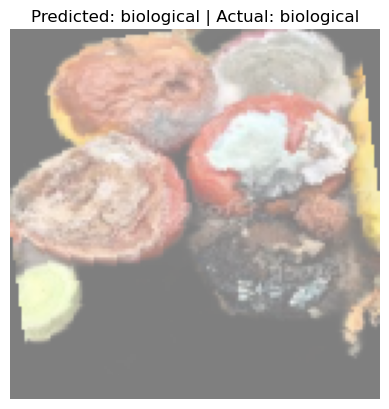

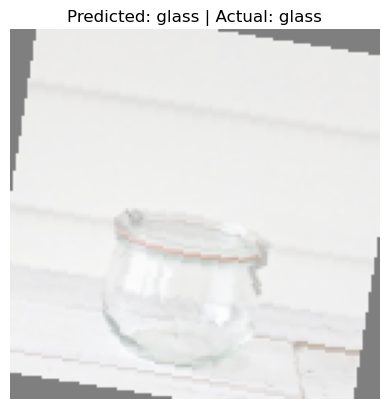

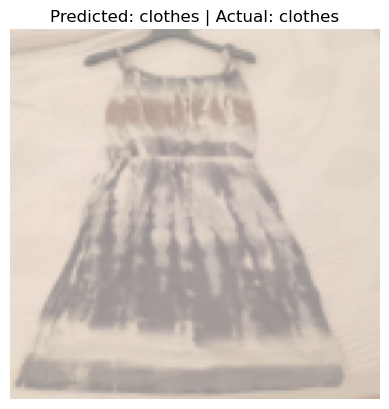

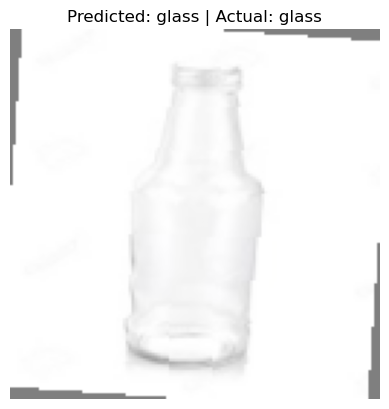

In [7]:
# Import necessary libraries
import matplotlib.pyplot as plt
import random

# Get class names from the dataset (matches folder names)
classes = dataset.classes

# Helper function to show an image with optional title
def imshow(img, title=None):
    img = img / 2 + 0.5          # Unnormalize the image (if normalized earlier)
    npimg = img.numpy()          # Convert tensor to NumPy array
    plt.imshow(np.transpose(npimg, (1, 2, 0)))   # Rearrange dimensions for display
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

# Get one batch from the validation loader
dataiter = iter(val_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# Randomly select 4 image indices from the batch
indices = random.sample(range(len(images)), 4)
sample_images = images[indices]
sample_labels = labels[indices]

# Run the model on these 4 images
model.eval()
with torch.no_grad():
    outputs = model(sample_images)
    _, predicted = torch.max(outputs, 1)

# Display each image with predicted and actual class names
for i in range(4):
    imshow(sample_images[i].cpu(), title=f"Predicted: {classes[predicted[i]]} | Actual: {classes[sample_labels[i]]}")

## 7. Confusion Matrix Visualization

We calculate and display a confusion matrix to evaluate how well the model performs on each class.

The confusion matrix shows:
- **Rows**: Actual class labels  
- **Columns**: Predicted class labels  
- Each cell shows how many images from a true class were predicted as another class

### Why It's Useful:
- Highlights which classes the model confuses most often  
- Helps evaluate performance for individual classes, not just overall accuracy  
- Useful for detecting systematic misclassifications

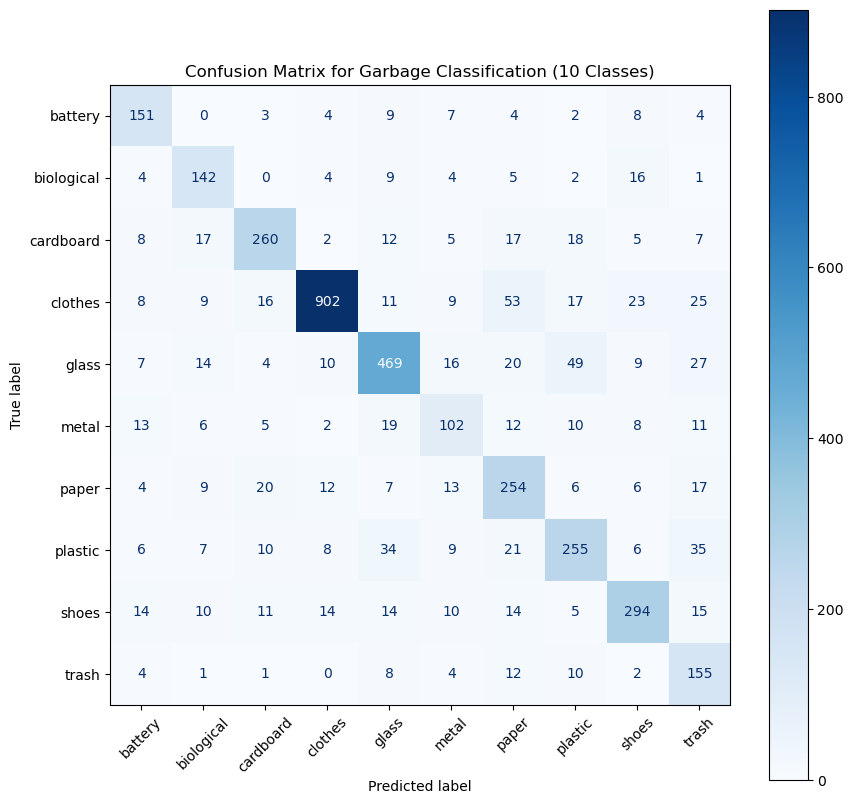

In [8]:
# Import necessary libraries
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Set model to evaluation mode
model.eval()

# Initialize lists to store all predictions and true labels
all_preds = []
all_labels = []

# Disable gradient computation for evaluation
with torch.no_grad():
    for inputs, labels in val_loader:
        # Move inputs and labels to the appropriate device
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Get model outputs
        outputs = model(inputs)
        
        # Get predicted class indices
        _, preds = torch.max(outputs, 1)        

        # Collect predictions and true labels
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Create a display object with class labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
plt.title("Confusion Matrix for Garbage Classification (10 Classes)")
plt.show()